In [2]:
import SimpleITK as sitk
import numpy as np 
import matplotlib.pyplot as plt 

img_sitk = sitk.ReadImage('3702_left_knee.nii') 
img_sitk

<SimpleITK.SimpleITK.Image; proxy of <Swig Object of type 'itk::simple::Image *' at 0x73c034161c80> >

In [64]:
image = sitk.GetArrayFromImage(img_sitk) 
image.shape

(216, 512, 512)

In [65]:
axial_index = image.shape[0] // 2      # 216 -> 108
coronal_index = image.shape[1] // 2    # 512 -> 256
sagittal_index = image.shape[2] // 2   # 512 -> 256

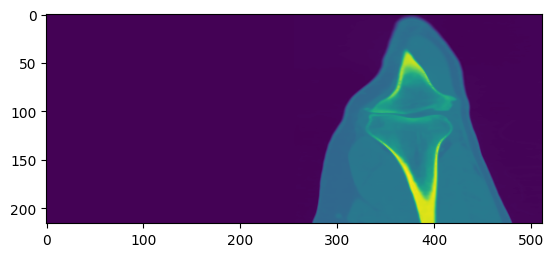

In [59]:
smoothed = sitk.CurvatureFlow(image1=img_sitk,
                               timeStep=0.225,
                               numberOfIterations=5)
plt.imshow(sitk.GetArrayFromImage(smoothed)[:, coronal_index, :])

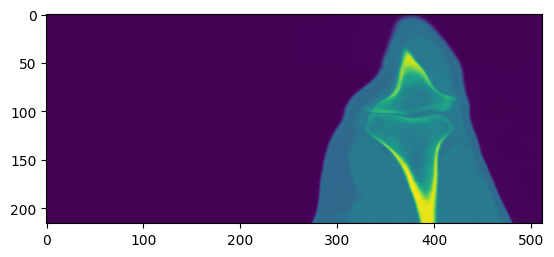

In [61]:
gaussian_blur = sitk.DiscreteGaussian(smoothed, variance=0.4)
gaussian_blur

plt.imshow(sitk.GetArrayFromImage(gaussian_blur)[:, coronal_index, :])

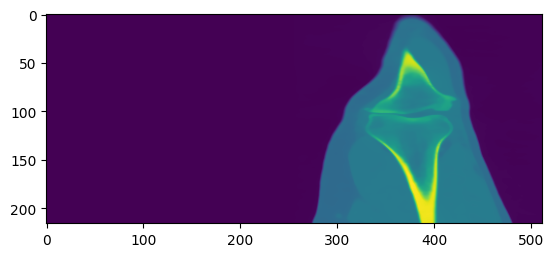

In [62]:
bilateral = sitk.Bilateral(gaussian_blur,
                           domainSigma=2.0,   # spatial extent
                           rangeSigma=50.0)
plt.imshow(sitk.GetArrayFromImage(bilateral)[:, coronal_index, :])

In [90]:
image_np = sitk.GetArrayFromImage(bilateral)
image_np.shape 

(216, 512, 512)

In [ ]:
axial_slice = image_np[axial_index, :, :]       # shape: (512, 512)
coronal_slice = image_np[:, coronal_index, :]   # shape: (216, 512)
sagittal_slice = image_np[:, :, sagittal_index] # shape: (216, 512)

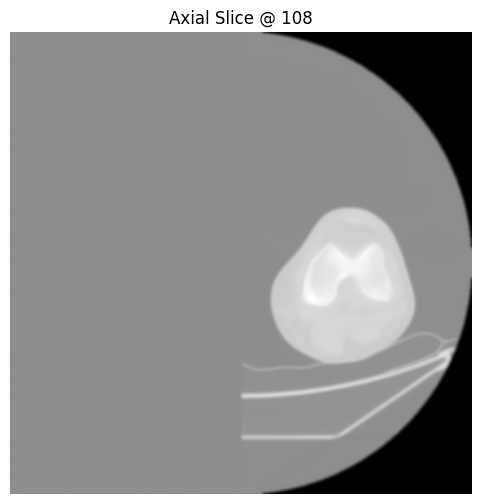

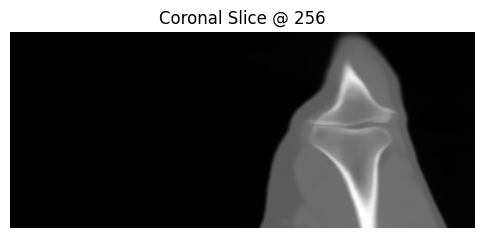

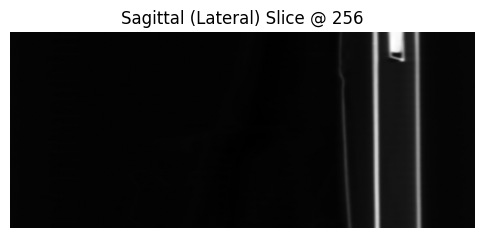

In [ ]:
plt.figure(figsize=(6, 6))
plt.imshow(axial_slice, cmap='gray')
plt.title(f'Axial Slice @ {axial_index}')
plt.axis('off')
plt.show()

plt.figure(figsize=(6, 6))
plt.imshow(coronal_slice, cmap='gray')
plt.title(f'Coronal Slice @ {coronal_index}')
plt.axis('off')
plt.show()

plt.figure(figsize=(6, 6))
plt.imshow(sagittal_slice, cmap='gray')
plt.title(f'Sagittal (Lateral) Slice @ {sagittal_index}')
plt.axis('off')
plt.show()

(216, 512, 512) <class 'numpy.ndarray'>


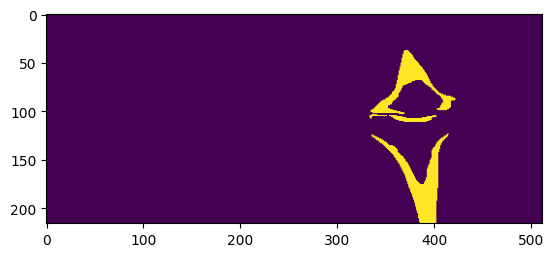

In [ ]:
from skimage import filters, measure, morphology, segmentation, color, exposure
from scipy import ndimage as ndi

image = image_np

blurred = filters.gaussian(image, sigma=0.1)
print(blurred.shape, type(blurred))


threshold = 390
binary = image > threshold

plt.imshow(binary[:, coronal_index, :])

In [ ]:
def segment_and_visualize_slice(mask_slice, slice_index=0, figsize=(15, 5)):
    """
    Segment and visualize a 2D slice of a 3D mask, showing intermediate and final results.
    
    Parameters:
    mask_slice (ndarray): 2D numpy array representing a slice of the 3D mask
    slice_index (int): Index of the slice for display purposes (default: 0)
    figsize (tuple): Figure size for the plot (default: (15, 5))
    """
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=figsize)
    
    ax1.imshow(mask_slice, cmap='gray')
    ax1.set_title(f"Original Mask Slice {slice_index}")
    ax1.axis('off')
    
    labeled = measure.label(mask_slice > 0)
    
    ax2.imshow(labeled, cmap='nipy_spectral')
    ax2.set_title(f"Labeled Components Slice {slice_index}")
    ax2.axis('off')
    
    props = measure.regionprops(labeled)
    props_sorted = sorted(props, key=lambda r: r.centroid[0])
    
    colored = np.zeros_like(labeled)
    if len(props_sorted) >= 2:
        colored[labeled == props_sorted[0].label] = 1  # Femur
        colored[labeled == props_sorted[1].label] = 2  # Tibia
    
    rgb = color.label2rgb(colored, colors=['red', 'blue'], bg_label=0)
    ax3.imshow(rgb)
    ax3.set_title(f"Segmented: Femur (Red), Tibia (Blue) Slice {slice_index}")
    ax3.axis('off')
    
    plt.tight_layout()
    plt.show()

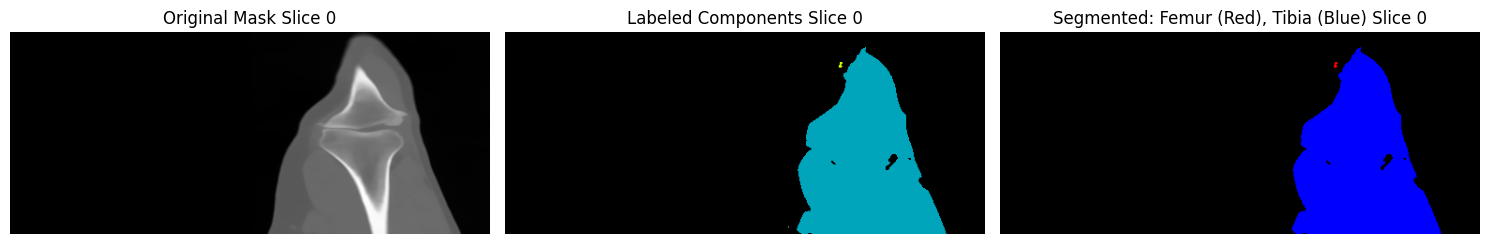

In [106]:
mask_slice = image_np[:, coronal_index, :]
segment_and_visualize_slice(mask_slice=mask_slice)